# Section 1 : Setting up HugginFace - Importing basics and Login.

In [1]:
import os
HF_TOKEN = os.getenv("HF_TOKEN")

In [2]:
from huggingface_hub import login
login(token=HF_TOKEN)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [3]:
!hf auth whoami

A new version of huggingface_hub (1.5.0) is available! You are using version 1.4.1.
To update, run: pip install -U huggingface_hub

user:  RonnieSDas


"https://huggingface.co/spaces/mrdbourke/trashify_demo_v4" - Final Project Demo looks like the one below:

In [4]:
from IPython.display import HTML 

HTML("""
<iframe
    src="https://mrdbourke-trashify-demo-v4.hf.space"
    frameborder="0"
    width="850"
    height="1150"
></iframe>
""")

In [5]:
import datasets
import gradio as gr
import torchmetrics 
import pycocotools
import random
import numpy as np
import torch
import transformers
from pprint import pprint


#Check package versions:
print(f"USING VERSIONS - \ttransformers : {transformers.__version__}, \t datasets : {datasets.__version__}, \t torch : {torch.__version__}, \t torchmetrics : {torchmetrics.__version__}")

USING VERSIONS - 	transformers : 5.2.0, 	 datasets : 4.5.0, 	 torch : 2.5.1+cu121, 	 torchmetrics : 1.8.2


NOTE: A tool for drawing boxes on images for object boundary detection is [Prodigy](https://prodi.gy/features/computer-vision)

# Section 2 :  Loading the dataset

In [6]:
from datasets import load_dataset
# load_dataset? #Basic class definition

In [7]:
dataset = load_dataset(path = "mrdbourke/trashify_manual_labelled_images")
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
        num_rows: 1128
    })
})

In [8]:
print(dataset['train']) # type(dataset) -> datasets.dataset_dict.DatasetDict | isinstance(dataset, datasets.dataset_dict.DatasetDict) -> True
type(dataset)

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
})


datasets.dataset_dict.DatasetDict

In [9]:
# Understanding the datatype of the dataset and how to access it. Comment and execute to see specific parts
print(dataset['train'], type(dataset['train']), '\n')

pprint(dataset['train'].features)
print("type of dataset['train'].features ", type(dataset['train'].features), '\n')

pprint(dataset['train'].features['annotations'])
print("type of dataset['train'].features['annotations'] ", type(dataset['train'].features['annotations']), '\n')

pprint(dataset['train'].features['annotations']['category_id'])
print("type of dataset['train'].features['annotations']['category_id'] ", type(dataset['train'].features['annotations']['category_id']), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature)
print("type of dataset['train'].features['annotations']['category_id'].feature ", type(dataset['train'].features['annotations']['category_id'].feature), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature.names)
print("type of dataset['train'].features['annotations']['category_id'].feature.names ", type(dataset['train'].features['annotations']['category_id'].feature.names), '\n')

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
}) <class 'datasets.arrow_dataset.Dataset'> 

{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}
type of dataset['train'].features  <class 'datasets.features.features.Features'> 

{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Valu

In [10]:
pprint(dataset['train'][0]) #Viewing a sample's features

{'annotations': {'area': [135381.078125, 1039532.4375],
                 'bbox': [[523.7000122070312,
                           545.0999755859375,
                           402.79998779296875,
                           336.1000061035156],
                          [10.399999618530273,
                           163.6999969482422,
                           943.4000244140625,
                           1101.9000244140625]],
                 'category_id': [1, 0],
                 'file_name': ['00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg',
                               '00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg'],
                 'image_id': [292, 292],
                 'iscrowd': [0, 0]},
 'image': <PIL.Image.Image image mode=RGB size=960x1280 at 0x7A7019B87140>,
 'image_id': 292,
 'image_source': 'manual_taken_photo',
 'label_source': 'manual_prodigy_label'}


In [11]:
print(type(dataset['train'].features))
pprint(dataset['train'].features) #Viewing all samples' features

<class 'datasets.features.features.Features'>
{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}


In [12]:
print(type(dataset['train'].features['annotations']))
pprint(dataset['train'].features['annotations']) # Accessing a specific key in the 'dataset["train"]' dict.
print('\n', type(dataset['train'].features['annotations'])) # Turns out each key is a dict as well. A nested dict structure.
print('\n', dataset['train'].features['annotations'].keys()) # Set of all keys inside the dict 'annotations' which happens to be a key of the dict 'dataset['train']'
print('\n', dataset['train'].features['annotations']['area']) # Accessing a specific key in the 'annotations' dict.

<class 'dict'>
{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Value('string')),
 'image_id': List(Value('int64')),
 'iscrowd': List(Value('int64'))}

 <class 'dict'>

 dict_keys(['file_name', 'image_id', 'category_id', 'bbox', 'iscrowd', 'area'])

 List(Value('float32'))


In [13]:
dataset['train'][2]['annotations']['bbox'][0] # This array gives us the coordinates of a single bounding box in the format XYWH.

[349.5, 677.2000122070312, 210.89999389648438, 376.0]

X is the x-coordinate of the top left corner of the box (349.5). \
Y is the y-coordinate of the top left corner of the box (677.2000122070312).\
W is the width of the box (210.89999389648438).\
H is the height of the box (376.0).

In [14]:
categories = dataset['train'].features['annotations']['category_id']
print(type(categories), dir(categories), "\n")
print(type(categories.feature), "\n")
print(categories)
print(categories.feature)
print(categories.feature.names)

<class 'datasets.features.features.List'> ['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__slotnames__', '__str__', '__subclasshook__', '__weakref__', '_type', 'feature', 'id', 'length', 'pa_type'] 

<class 'datasets.features.features.ClassLabel'> 

List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']))
ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])
['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']


In [15]:
# Creating a mapping from numbers to labels
id2label = {i:class_name for i, class_name in enumerate(categories.feature.names)}
print(id2label.items())
label2id = {value:key for key, value in id2label.items()}
print(label2id.items())

dict_items([(0, 'bin'), (1, 'hand'), (2, 'not_bin'), (3, 'not_hand'), (4, 'not_trash'), (5, 'trash'), (6, 'trash_arm')])
dict_items([('bin', 0), ('hand', 1), ('not_bin', 2), ('not_hand', 3), ('not_trash', 4), ('trash', 5), ('trash_arm', 6)])


In [16]:
# Creating a colour palette
# Make colour dictionary
colour_palette = {
    'bin': (0, 0, 224),         # Bright Blue (High contrast with greenery) in format (red, green, blue)
    'not_bin': (255, 80, 80),   # Light Red to indicate negative class

    'hand': (148, 0, 211),      # Dark Purple (Contrasts well with skin tones)
    'not_hand': (255, 80, 80),  # Light Red to indicate negative class

    'trash': (0, 255, 0),       # Bright Green (For trash-related items)
    'not_trash': (255, 80, 80), # Light Red to indicate negative class

    'trash_arm': (255, 140, 0), # Deep Orange (Highly visible)
}

pprint(colour_palette)

{'bin': (0, 0, 224),
 'hand': (148, 0, 211),
 'not_bin': (255, 80, 80),
 'not_hand': (255, 80, 80),
 'not_trash': (255, 80, 80),
 'trash': (0, 255, 0),
 'trash_arm': (255, 140, 0)}


We’ll just have to write a small function to normalize our colour values from [0, 255] to [0, 1] \
 (matplotlib expects our colour values to be between 0 and 1).


[('bin', (0.0, 0.0, 0.8784313725490196)),
 ('not_bin', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('hand', (0.5803921568627451, 0.0, 0.8274509803921568)),
 ('not_hand', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('trash', (0.0, 1.0, 0.0)),
 ('not_trash', (1.0, 0.3137254901960784, 0.3137254901960784)),
 ('trash_arm', (1.0, 0.5490196078431373, 0.0))]

 <class 'list'>


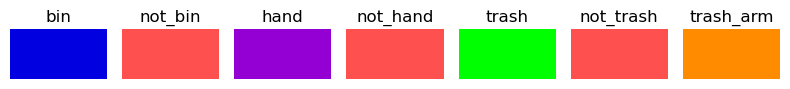

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Normalize RGB values between 0-1 range:
def normalize_rgb(rgb_tuple):
    return tuple(x/255 for x in rgb_tuple)

# Turn colors into normalized RGB values for matplotlib
colors_and_labels_rgb  = [(key, normalize_rgb(value)) for (key, value) in colour_palette.items()]
pprint(colors_and_labels_rgb) 
print('\n',type(colors_and_labels_rgb))

# Create figure and axis
fig, ax = plt.subplots(1, 7, figsize = (8,1))

# Flatten the axis array for easier iteration
ax = ax.flatten()

# Plot each color square
for idx, (label, color) in enumerate(colors_and_labels_rgb):
    ax[idx].add_patch(plt.Rectangle(xy=(0, 0), 
                                    width=1, 
                                    height=1, 
                                    facecolor=color))
    ax[idx].set_title(label)
    ax[idx].set_xlim(0, 1)
    ax[idx].set_ylim(0, 1)
    ax[idx].axis('off')

plt.tight_layout()
plt.show()

# Section 3 : Plotting an image from the loaded dataset and visualizing the bounding boxes

In [18]:
# To make the images fit in the notebook window, it is important to create a function to make them smaller

import PIL

def half_image(image: PIL.Image) -> PIL.Image:
    """
    Resizes a given input image by half and returns the smaller version.
    """
    return image.resize(size=(image.size[0] // 2, image.size[1] // 2))

def half_boxes(boxes):
    """
    Halves an array/tensor of input boxes and returns them. Necessary for plotting them on a half-sized image.

    For example:

    boxes = [100, 100, 100, 100]
    half_boxes = half_boxes(boxes)
    print(half_boxes)

    >>> [50, 50, 50, 50]
    """
    if isinstance(boxes, list):
        # If boxes are list of lists, then we have multiple boxes
        for box in boxes:
            if isinstance(box, list):
                return [[coordinate // 2 for coordinate in box] for box in boxes]
            else:
                return [coordinate // 2 for coordinate in boxes]         
    
    if isinstance(boxes, np.ndarray):
        return (boxes // 2)
    
    if isinstance(boxes, torch.Tensor):
        return (boxes // 2)

# Test the functions 
image_test = dataset["train"][42]["image"]
image_test_half = half_image(image_test)
print(f"[INFO] Original image size: {image_test.size} | Half image size: {image_test_half.size}")

boxes_test_list = [100, 100, 100, 100]
print(f"[INFO] Original boxes: {boxes_test_list} | Half boxes: {half_boxes(boxes_test_list)}")

boxes_test_torch = torch.tensor([100.0, 100.0, 100.0, 100.0])
print(f"[INFO] Original boxes: {boxes_test_torch} | Half boxes: {half_boxes(boxes_test_torch)}")


[INFO] Original image size: (960, 1280) | Half image size: (480, 640)
[INFO] Original boxes: [100, 100, 100, 100] | Half boxes: [50, 50, 50, 50]
[INFO] Original boxes: tensor([100., 100., 100., 100.]) | Half boxes: tensor([50., 50., 50., 50.])


Plotting boxes on a single image step by step

[INFO] Showing training sample from index: 183 - 
Boxes in XYWH format: tensor([[230., 287.,  62., 138.],
        [134., 390., 139., 168.],
        [120., 182., 252., 285.],
        [  1., 196., 132., 343.]])
Boxes in XYXY format: tensor([[230., 287., 292., 425.],
        [134., 390., 273., 558.],
        [120., 182., 372., 467.],
        [  1., 196., 133., 539.]])

Label names: ['trash', 'hand', 'bin', 'bin']
Colour codes: [(0, 255, 0), (148, 0, 211), (0, 0, 224), (0, 0, 224)]


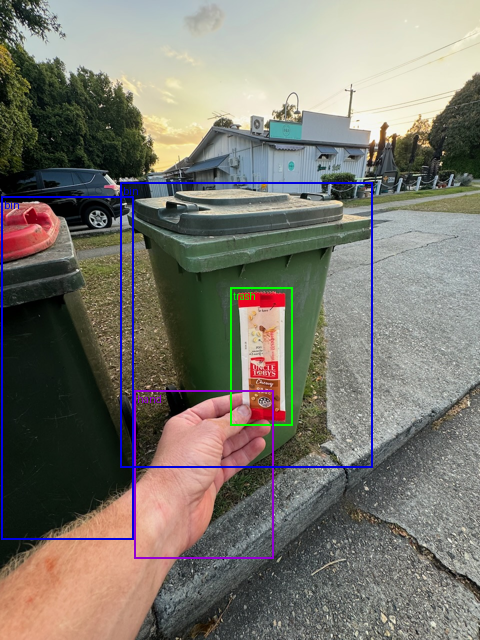

In [19]:
import random
import torch
from torchvision.ops import box_convert
from torchvision.utils import draw_bounding_boxes
from torchvision.transforms.functional import pil_to_tensor, to_pil_image

# Step 1 : Select a random sample from the loaded dataset
random_index = random.randint(0, len(dataset['train']))
random_sample = dataset['train'][random_index]
print(f"[INFO] Showing training sample from index: {random_index} - ")

# Step 2 : Get image and boxes from random_sample
random_sample_image = random_sample['image']
random_sample_boxes = random_sample['annotations']['bbox']  
# Optional: Half the image and boxes for space saving (all of the following code will work with/without half size images)
half_random_sample_image = half_image(random_sample_image)
half_random_sample_boxes = half_boxes(random_sample_boxes)

# Step 3. Turn box coordinates in a tensor
boxes_xywh = torch.tensor(half_random_sample_boxes)
print(f"Boxes in XYWH format: {boxes_xywh}")

# Step 4. Convert coordinates from XYWH to XYXY (since torchvision.utils.draw_bounding_boxes requires input boxes in XYXY format (X_min, y_min, X_max, y_max))
boxes_xyxy = box_convert(boxes = boxes_xywh, in_fmt = 'xywh', out_fmt = 'xyxy')
print(f"Boxes in XYXY format: {boxes_xyxy}\n")

# Step 5. Get label names of target boxes and colours to match
random_sample_label_names = [categories.feature.names[x] for x in random_sample["annotations"]["category_id"]] 
random_sample_colours = [colour_palette[label] for label in random_sample_label_names]
print(f"Label names: {random_sample_label_names}")
print(f"Colour codes: {random_sample_colours}")

# Step 6. Converting half_random_sample_image from pil to tensor in order to use draw_bounding_boxes, then after the boxes are drawn on the image, using to_pil_image to plot the image with the bboxes drawn on it
to_pil_image(
    pic = draw_bounding_boxes(
        image = pil_to_tensor(pic = half_random_sample_image),
        boxes = boxes_xyxy,
        colors = random_sample_colours,
        labels = random_sample_label_names,
        width = 2,
        # label_colors = random_sample_colours
    )
)


In [20]:
# Re-Understanding the datatype of the dataset and how to access it.
print(dataset['train'], type(dataset['train']), '\n')

pprint(dataset['train'].features)
print("type of dataset['train'].features ", type(dataset['train'].features), '\n')

pprint(dataset['train'].features['annotations'])
print("type of dataset['train'].features['annotations'] ", type(dataset['train'].features['annotations']), '\n')

Dataset({
    features: ['image', 'image_id', 'annotations', 'label_source', 'image_source'],
    num_rows: 1128
}) <class 'datasets.arrow_dataset.Dataset'> 

{'annotations': {'area': List(Value('float32')),
                 'bbox': List(List(Value('float32'), length=4)),
                 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
                 'file_name': List(Value('string')),
                 'image_id': List(Value('int64')),
                 'iscrowd': List(Value('int64'))},
 'image': Image(mode=None, decode=True),
 'image_id': Value('int64'),
 'image_source': Value('string'),
 'label_source': Value('string')}
type of dataset['train'].features  <class 'datasets.features.features.Features'> 

{'area': List(Value('float32')),
 'bbox': List(List(Value('float32'), length=4)),
 'category_id': List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm'])),
 'file_name': List(Valu

In [21]:
pprint(dataset['train'].features['annotations']['category_id'])
print("type of dataset['train'].features['annotations']['category_id'] ", type(dataset['train'].features['annotations']['category_id']), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature)
print("type of dataset['train'].features['annotations']['category_id'].feature ", type(dataset['train'].features['annotations']['category_id'].feature), '\n')

pprint(dataset['train'].features['annotations']['category_id'].feature.names)
print("type of dataset['train'].features['annotations']['category_id'].feature.names ", type(dataset['train'].features['annotations']['category_id'].feature.names), '\n')

List(ClassLabel(names=['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']))
type of dataset['train'].features['annotations']['category_id']  <class 'datasets.features.features.List'> 

ClassLabel(names=['bin',
                  'hand',
                  'not_bin',
                  'not_hand',
                  'not_trash',
                  'trash',
                  'trash_arm'])
type of dataset['train'].features['annotations']['category_id'].feature  <class 'datasets.features.features.ClassLabel'> 

['bin', 'hand', 'not_bin', 'not_hand', 'not_trash', 'trash', 'trash_arm']
type of dataset['train'].features['annotations']['category_id'].feature.names  <class 'list'> 



# Section 4 : Creating the model

In [22]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="torch.nn.modules.module")  # turn off warnings for loading the model (feel free to comment this if you want to see the warnings)

from transformers import AutoModelForObjectDetection
# help(AutoModelForObjectDetection)

MODEL_NAME = "PekingU/rtdetr_v2_r50vd"

model = AutoModelForObjectDetection.from_pretrained(
    pretrained_model_name_or_path = MODEL_NAME,
    label2id = label2id,
    id2label = id2label,
    ignore_mismatched_sizes = True     # Original model was trained with a different number of output classes to ours
                                       # So we'll ignore any mismatched sizes (e.g. 91 vs. 7)
)

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([8, 256])
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.enc_sco

In [23]:
model, type(model)

(RTDetrV2ForObjectDetection(
   (model): RTDetrV2Model(
     (backbone): RTDetrV2ConvEncoder(
       (model): RTDetrResNetBackbone(
         (embedder): RTDetrResNetEmbeddings(
           (embedder): Sequential(
             (0): RTDetrResNetConvLayer(
               (convolution): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
               (normalization): RTDetrV2FrozenBatchNorm2d()
               (activation): ReLU()
             )
             (1): RTDetrResNetConvLayer(
               (convolution): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
               (normalization): RTDetrV2FrozenBatchNorm2d()
               (activation): ReLU()
             )
             (2): RTDetrResNetConvLayer(
               (convolution): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
               (normalization): RTDetrV2FrozenBatchNorm2d()
               (activation): ReLU()
             )
         

In [24]:
print(f"[INFO] Final classification layer: {model.class_embed}\n") # 7 output classes
print(f"[INFO] Final box regression layer: {model.bbox_embed}") # 4 boundary box coordinates

[INFO] Final classification layer: ModuleList(
  (0-5): 6 x Linear(in_features=256, out_features=7, bias=True)
)

[INFO] Final box regression layer: ModuleList(
  (0-5): 6 x RTDetrV2MLPPredictionHead(
    (layers): ModuleList(
      (0-1): 2 x Linear(in_features=256, out_features=256, bias=True)
      (2): Linear(in_features=256, out_features=4, bias=True)
    )
  )
)


In [25]:
#List only public callables
import inspect

[name for name, obj in inspect.getmembers(model) 
 if callable(obj) and not name.startswith("_")]

# help(model)

['active_adapters',
 'add_adapter',
 'add_model_tags',
 'add_module',
 'apply',
 'base_model',
 'bbox_embed',
 'bfloat16',
 'buffers',
 'can_generate',
 'children',
 'class_embed',
 'compile',
 'config_class',
 'cpu',
 'create_extended_attention_mask_for_decoder',
 'cuda',
 'delete_adapter',
 'dequantize',
 'disable_adapters',
 'disable_input_require_grads',
 'double',
 'enable_adapters',
 'enable_input_require_grads',
 'enable_peft_hotswap',
 'eval',
 'extra_repr',
 'float',
 'forward',
 'from_pretrained',
 'get_adapter_state_dict',
 'get_buffer',
 'get_compiled_call',
 'get_correct_attn_implementation',
 'get_correct_experts_implementation',
 'get_decoder',
 'get_encoder',
 'get_expanded_tied_weights_keys',
 'get_extended_attention_mask',
 'get_extra_state',
 'get_init_context',
 'get_input_embeddings',
 'get_memory_footprint',
 'get_output_embeddings',
 'get_parameter',
 'get_parameter_or_buffer',
 'get_position_embeddings',
 'get_submodule',
 'gradient_checkpointing_disable',
 'gra

In [26]:
print(model.config) # model configurations like hyperparameters and stuff

for name, param in model.named_parameters(): # all model parameters
    print(name, type(name), param.shape, type(param), param.numel())


RTDetrV2Config {
  "activation_dropout": 0.0,
  "activation_function": "silu",
  "anchor_image_size": null,
  "architectures": [
    "RtDetrV2ForObjectDetection"
  ],
  "attention_dropout": 0.0,
  "auxiliary_loss": true,
  "backbone": null,
  "backbone_config": {
    "depths": [
      3,
      4,
      6,
      3
    ],
    "downsample_in_bottleneck": false,
    "downsample_in_first_stage": false,
    "dtype": "float32",
    "embedding_size": 64,
    "hidden_act": "relu",
    "hidden_sizes": [
      256,
      512,
      1024,
      2048
    ],
    "layer_type": "bottleneck",
    "model_type": "rt_detr_resnet",
    "num_channels": 3,
    "out_features": [
      "stage2",
      "stage3",
      "stage4"
    ],
    "out_indices": [
      2,
      3,
      4
    ],
    "stage_names": [
      "stem",
      "stage1",
      "stage2",
      "stage3",
      "stage4"
    ]
  },
  "batch_norm_eps": 1e-05,
  "box_noise_scale": 1.0,
  "d_model": 256,
  "decoder_activation_function": "relu",
  "deco

In [27]:
for p in model.parameters():
    print(p.shape, ' | ', type(p), ' | ', p.numel(), ' | ', p.requires_grad)

torch.Size([32, 3, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  864  |  True
torch.Size([32, 32, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  9216  |  True
torch.Size([64, 32, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  18432  |  True
torch.Size([256, 64, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 64, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  4096  |  True
torch.Size([64, 64, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  36864  |  True
torch.Size([256, 64, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 256, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 64, 3, 3])  |  <class 'torch.nn.parameter.Parameter'>  |  36864  |  True
torch.Size([256, 64, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 256, 1, 1])  |  <class 'torch.nn.parameter.Parameter'>  |  16384  |  True
torch.Size([64, 64, 3

In [28]:
# Counting the total number of parameters in the loaded model (trainable / frozen):
def count_parameters(model):
    trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
    non_trainable_parameters = sum(p.numel() for p in model.parameters() if not p.requires_grad)
    total_parameters = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_parameters:,}")
    print(f"Trainable parameters (will be updated): {trainable_parameters:,}")
    print(f"Non-trainable parameters (will not be updated): {non_trainable_parameters:,}")

count_parameters(model)

Total parameters: 42,741,357
Trainable parameters (will be updated): 42,741,357
Non-trainable parameters (will not be updated): 0


Creating a function to build a model

In [29]:
from transformers import AutoModelForObjectDetection

def create_model(pretrained_model_name_or_path: str = MODEL_NAME,
                 label2id: dict = label2id,
                 id2label: dict = id2label) -> AutoModelForObjectDetection:
    """Creates and returns an instance of AutoModelForObjectDetection.
    
    Args: 
        pretrained_model_name_or_path (str): The name or path of the pretrained model to load. 
            Defaults to MODEL_NAME.
        label2id (dict): A dictionary mapping class labels to IDs. Defaults to label2id.
        id2label (dict): A dictionary mapping class IDs to labels. Defaults to id2label.
    
    Returns:
        AutoModelForObjectDetection: A pretrained model for object detection with number of output
            classes equivalent to len(label2id).
    """
    model = AutoModelForObjectDetection.from_pretrained(pretrained_model_name_or_path = pretrained_model_name_or_path,
                                        label2id = label2id,
                                        id2label = id2label,
                                        ignore_mismatched_sizes = True)
    return model

In [30]:
model = create_model()

Loading weights:   0%|          | 0/770 [00:00<?, ?it/s]

RTDetrV2ForObjectDetection LOAD REPORT from: PekingU/rtdetr_v2_r50vd
Key                                                 | Status   |                                                                                        
----------------------------------------------------+----------+----------------------------------------------------------------------------------------
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80, 256]) vs model:torch.Size([7, 256])
model.decoder.class_embed.{0, 1, 2, 3, 4, 5}.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.denoising_class_embed.weight                  | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([81, 256]) vs model:torch.Size([8, 256])
model.enc_score_head.bias                           | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([80]) vs model:torch.Size([7])          
model.enc_sco

Trying to pass a single sample through the model

In [31]:
model.forward?

Signature:
model.forward(
    pixel_values: torch.FloatTensor,
    pixel_mask: torch.LongTensor | None = None,
    encoder_outputs: torch.FloatTensor | None = None,
    inputs_embeds: torch.FloatTensor | None = None,
    labels: list[dict] | None = None,
    **kwargs: Unpack[transformers.utils.generic.TransformersKwargs],
) -> tuple[torch.FloatTensor] | transformers.models.rt_detr_v2.modeling_rt_detr_v2.RTDetrV2ObjectDetectionOutput
Docstring:
The [`RTDetrV2ForObjectDetection`] forward method, overrides the `__call__` special method.

<Tip>

Although the recipe for forward pass needs to be defined within this function, one should call the [`Module`]
instance afterwards instead of this since the former takes care of running the pre and post processing steps while
the latter silently ignores them.

</Tip>

Args:
    pixel_values (`torch.FloatTensor` of shape `(batch_size, num_channels, image_size, image_size)`):
        The tensors corresponding to the input images. Pixel values can be o

In [32]:
# Trying to do a single forward pass through the model
random_sample_outputs = model(pixel_values = random_sample['image'], pixel_mask = None)
random_sample_outputs = model(pixel_values = random_sample['image'], pixel_mask = None)


AttributeError: 'Image' object has no attribute 'shape'

 It seems I've tried to pass a PIL.Image to our model rather than a torch.FloatTensor of shape (batch_size, num_channels, height, width). \
 It looks like the input data might require some preprocessing before we can pass it to our model.

# Section 5 : Processor to Model Pattern

<!-- ![Preprocessing Pipeline](/home/suhdas/development/research/DL_Backbone_Implementations/Object_Detection_with_HF_Transformers/images_ipynb/image.png) -->
<div style="text-align: center;">
  <img src="/home/suhdas/development/research/DL_Backbone_Implementations/Object_Detection_with_HF_Transformers/images_ipynb/image.png" alt="Centered image" width="900" height="400">
</div>

Start with images labelled with boxes of trash, bin and hand (and other classes), preprocess the images to be ready for use with a model and then train the model on the preprocessed custom data. 

In [33]:
# Example Preprocess to Inference pipeline:

from transformers import AutoProcessor, AutoModel

# Load raw data
raw_data = load_data()

# Define target model name
MODEL_NAME = "..."

# Load preprocessor and model (these two are often paired)
preprocessor = AutoProcessor.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

# Preprocess data
preprocessed_data = preprocessor.preprocess(raw_data)

# Pass preprocessed data to model
output = model(preprocessed_data)

NameError: name 'load_data' is not defined

# Section 6 : Loading the model's Preprocessor

In [34]:
from transformers import AutoImageProcessor

MODEL_NAME = "PekingU/rtdetr_v2_r50vd" # MODEL_NAME = "facebook/detr-resnet-50" # Could also use this model as an another experiment

# Loading the image processor
image_processor = AutoImageProcessor.from_pretrained(pretrained_model_name_or_path=MODEL_NAME,
                                                     use_fast=True) # load the fast version of the processor

image_processor

RTDetrImageProcessorFast {
  "data_format": "channels_first",
  "do_convert_annotations": true,
  "do_normalize": false,
  "do_pad": false,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "RTDetrImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 640,
    "width": 640
  }
}

One of the first things to see is the image_processor is expecting the bounding boxes to be in COCO format (see the "format": coco_detection field, this is the default).\
Another thing to notice is that the input images will be resized to the values of the size parameter.\ 

do_convert_annotations=True - This is the default and it will convert the boxes to the format CXCYWH or (center_x, center_y, width, height)\
size - We’ll update the size dictionary so all of our images have "longest_edge": 640 and "shortest_edge: 640"\
do_pad=True - Make sure to pad our images with 0 pixels so that all images in the same batch have the same size. For example if an image has the dimensions image_1 = (640, 480) but the largest image in the batch is (640, 640), image_1 will be padded with 0 to have its dimensions equal (640, 640). This will only happen during batch processing rather than individual image processing. See the do_pad parameter documentation for more.

In [35]:
# Set image size
IMAGE_SIZE = 640 # we could try other sizes here: 300x300, 480x480, 512x512, 640x640, 800x800 (best to experiment and see which works best)

# Create a new instance of the image processor with the desired image size
image_processor = AutoImageProcessor.from_pretrained(
    pretrained_model_name_or_path=MODEL_NAME,
    use_fast=True, # use the fast preprocessor
    format="coco_detection", # this is the default
    do_convert_annotations=True, # defaults to True, converts boxes to (center_x, center_y, width, height) in range [0, 1]
    size={"shortest_edge": IMAGE_SIZE, 
          "longest_edge": IMAGE_SIZE},
    return_segmentation_masks=True,
    do_pad=True # make sure all images have 640x640 size thanks to padding
)

image_processor.size, type(image_processor.size), image_processor.size.keys()

({'shortest_edge': 640, 'longest_edge': 640},
 dict,
 dict_keys(['shortest_edge', 'longest_edge']))

In [36]:
image_processor

RTDetrImageProcessorFast {
  "data_format": "channels_first",
  "do_convert_annotations": true,
  "do_normalize": false,
  "do_pad": true,
  "do_rescale": true,
  "do_resize": true,
  "format": "coco_detection",
  "image_mean": [
    0.485,
    0.456,
    0.406
  ],
  "image_processor_type": "RTDetrImageProcessorFast",
  "image_std": [
    0.229,
    0.224,
    0.225
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "return_segmentation_masks": true,
  "size": {
    "longest_edge": 640,
    "shortest_edge": 640
  }
}

In [37]:
# Try to process a single image and annotation pair (spoiler: this will error)
random_sample_preprocessed = image_processor.preprocess(images = random_sample['image'],
                                                        annotations = random_sample['annotations'])

StrictDataclassFieldValidationError: Validation error for field 'annotations':
    TypeError: Field 'annotations' with value {'file_name': ['2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg', '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg', '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg', '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg'], 'image_id': [910, 910, 910, 910], 'category_id': [5, 1, 0, 0], 'bbox': [[460.29998779296875, 575.5, 124.30000305175781, 276.1000061035156], [268.5, 781.4000244140625, 279.0, 336.0], [241.89999389648438, 364.8999938964844, 505.0, 571.5999755859375], [3.799999952316284, 392.0, 265.3999938964844, 687.0999755859375]], 'iscrowd': [0, 0, 0, 0], 'area': [34319.23046875, 93744.0, 288658.0, 182356.34375]} doesn't match any type in (dict[str, int | str | list[dict]], list[dict[str, int | str | list[dict]]], <class 'NoneType'>). Errors: Invalid key or value in dict 'annotations'; Field 'annotations' expected a list, got dict; Field 'annotations' expected NoneType, got dict (value: 

It turns out that the annotations aren’t in the format that the preprocess method was expecting.\
Since the pre-trained model was trained on the COCO dataset, the preprocess method expects input data to be in line with the COCO format.\
TODO : Fix this later on by adjusting the annotations.\
Try to preprocess just a single image instead.

In [38]:
# Preprocess the target sample
random_sample_preprocessed_image_only = image_processor(images=random_sample["image"], # here random sample is one random sample from the entire dataset.
                                                        annotations=None, # no annotations this time 
                                                        masks_path=None, # no masks inputs
                                                        return_tensors="pt") # return as PyTorch tensors
print(type(random_sample_preprocessed_image_only)) 
print(random_sample_preprocessed_image_only.keys()) #random_sample_preprocessed_image_only

<class 'transformers.image_processing_base.BatchFeature'>
KeysView({'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[0.2784, 0.3216, 0.2078,  ..., 0.8510, 0.8510, 0.8510],
          [0.2196, 0.2706, 0.1765,  ..., 0.8510, 0.8510, 0.8510],
          [0.3686, 0.3765, 0.1686,  ..., 0.8510, 0.8510, 0.8510],
          ...,
          [0.8667, 0.8706, 0.8706,  ..., 0.5098, 0.4392, 0.2706],
          [0.8706, 0.8667, 0.8706,  ..., 0.5451, 0.4627, 0.3216],
          [0.8667, 0.8667, 0.8745,  ..., 0.5373, 0.5569, 0.4000]],

         [[0.3255, 0.3569, 0.2353,  ..., 0.8471, 0.8471, 0.8471],
          [0.2588, 0.3020, 0.2000,  ..., 0.8471, 0.8471, 0.8471],
          [0.3961, 0.4000, 0.1843,  ..., 0.8471, 0.8471, 0.8471],
          ...,
          [0.6000, 0.6039, 0.6118,  ..., 0.5020, 

In [39]:
random_sample_preprocessed_image_only['pixel_mask'], random_sample_preprocessed_image_only.pixel_values

(tensor([[[1, 1, 1,  ..., 1, 1, 1],
          [1, 1, 1,  ..., 1, 1, 1],
          [1, 1, 1,  ..., 1, 1, 1],
          ...,
          [1, 1, 1,  ..., 1, 1, 1],
          [1, 1, 1,  ..., 1, 1, 1],
          [1, 1, 1,  ..., 1, 1, 1]]]),
 tensor([[[[0.2784, 0.3216, 0.2078,  ..., 0.8510, 0.8510, 0.8510],
           [0.2196, 0.2706, 0.1765,  ..., 0.8510, 0.8510, 0.8510],
           [0.3686, 0.3765, 0.1686,  ..., 0.8510, 0.8510, 0.8510],
           ...,
           [0.8667, 0.8706, 0.8706,  ..., 0.5098, 0.4392, 0.2706],
           [0.8706, 0.8667, 0.8706,  ..., 0.5451, 0.4627, 0.3216],
           [0.8667, 0.8667, 0.8745,  ..., 0.5373, 0.5569, 0.4000]],
 
          [[0.3255, 0.3569, 0.2353,  ..., 0.8471, 0.8471, 0.8471],
           [0.2588, 0.3020, 0.2000,  ..., 0.8471, 0.8471, 0.8471],
           [0.3961, 0.4000, 0.1843,  ..., 0.8471, 0.8471, 0.8471],
           ...,
           [0.6000, 0.6039, 0.6118,  ..., 0.5020, 0.4196, 0.2431],
           [0.6039, 0.6039, 0.6118,  ..., 0.5412, 0.4471, 0.2

It looks like the preprocess method works on a single image.\
And it seems like we get a dictionary output with the following keys:\
    **pixel_values** - the processed pixel values of the input image.\
    (Optional) **pixel_mask** - a mask multiplier for the pixel values as to whether they should be paid attention to or not (a value of 0 means the pixel value should be ignored by the model and a value of 1 means the pixel value should be paid attention to by the model)

In [40]:
print(f"[INFO] Original image shape: {random_sample['image'].size} -> [width, height]")
print(f"[INFO] Preprocessed image shape: {random_sample_preprocessed_image_only['pixel_values'].shape} -> [batch_size, colour_channles, height, width] \n")

print(random_sample_preprocessed_image_only["pixel_values"][0])

[INFO] Original image shape: (960, 1280) -> [width, height]
[INFO] Preprocessed image shape: torch.Size([1, 3, 640, 480]) -> [batch_size, colour_channles, height, width] 

tensor([[[0.2784, 0.3216, 0.2078,  ..., 0.8510, 0.8510, 0.8510],
         [0.2196, 0.2706, 0.1765,  ..., 0.8510, 0.8510, 0.8510],
         [0.3686, 0.3765, 0.1686,  ..., 0.8510, 0.8510, 0.8510],
         ...,
         [0.8667, 0.8706, 0.8706,  ..., 0.5098, 0.4392, 0.2706],
         [0.8706, 0.8667, 0.8706,  ..., 0.5451, 0.4627, 0.3216],
         [0.8667, 0.8667, 0.8745,  ..., 0.5373, 0.5569, 0.4000]],

        [[0.3255, 0.3569, 0.2353,  ..., 0.8471, 0.8471, 0.8471],
         [0.2588, 0.3020, 0.2000,  ..., 0.8471, 0.8471, 0.8471],
         [0.3961, 0.4000, 0.1843,  ..., 0.8471, 0.8471, 0.8471],
         ...,
         [0.6000, 0.6039, 0.6118,  ..., 0.5020, 0.4196, 0.2431],
         [0.6039, 0.6039, 0.6118,  ..., 0.5412, 0.4471, 0.2980],
         [0.5922, 0.6039, 0.6157,  ..., 0.5333, 0.5451, 0.3765]],

        [[0.2392

Trying to pass a single sample through the model (AGAIN)

In [41]:
# Do a single forward pass with the model
random_sample_outputs = model(
    pixel_values=random_sample_preprocessed_image_only["pixel_values"], # model expects input [batch_size, color_channels, height, width]
    # pixel_mask=random_sample_preprocessed_image_only["pixel_mask"], # some object detection models expect masks
) # same as model.forward(pixel_values, pixel_mask)

In [42]:
print(random_sample_outputs, '\n')
random_sample_outputs.keys()

RTDetrV2ObjectDetectionOutput(loss=None, loss_dict=None, logits=tensor([[[-0.4260, -0.7219, -1.5186,  ..., -0.3495, -1.6482, -3.1339],
         [-0.2255, -1.0513, -1.8538,  ..., -0.1056, -2.0944, -2.9652],
         [-0.3124, -0.7825, -1.5945,  ..., -0.5226, -1.4300, -3.0050],
         ...,
         [-0.0084, -0.7250, -1.3670,  ..., -0.4885, -1.6602, -3.0091],
         [ 0.2742, -0.7092, -1.5048,  ..., -0.6480, -1.3961, -3.1420],
         [-0.3221, -1.0156, -1.6028,  ..., -0.3112, -1.7942, -3.4048]]],
       grad_fn=<SelectBackward0>), pred_boxes=tensor([[[0.8506, 0.3480, 0.2365, 0.0481],
         [0.8592, 0.8916, 0.2736, 0.2076],
         [0.8661, 0.3519, 0.1909, 0.0431],
         ...,
         [0.7572, 0.5692, 0.1382, 0.2761],
         [0.4753, 0.5048, 0.5937, 0.3985],
         [0.5411, 0.8279, 0.4544, 0.3222]]], grad_fn=<SelectBackward0>), auxiliary_outputs=None, last_hidden_state=tensor([[[ 0.2861,  1.3485, -0.0739,  ..., -0.1693, -0.1346, -0.8261],
         [ 0.0411,  0.8419,  0.53

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'intermediate_hidden_states', 'intermediate_logits', 'intermediate_reference_points', 'encoder_last_hidden_state', 'init_reference_points', 'enc_topk_logits', 'enc_topk_bboxes', 'enc_outputs_class', 'enc_outputs_coord_logits'])


**logits** - The raw outputs from the model, these are the classification logits. Later, apply a softmax function/sigmoid function to to get prediction probabilties.\
**pred_boxes** - Normalized box coordinates in CXCYWH ((center_x, center_y, width, height)) format.\
**last_hidden_state** - Last hidden state of the last decoder layer of the model.\
**encoder_last_hidden_state** - Last hidden state of the last encoder layer of the model.


In [43]:
# Inspect logits output shape
output_logits = random_sample_outputs.logits
print(f"[INFO] Output logits shape: {output_logits.shape} -> [1 image, 300 boxes, 7 classes]")

[INFO] Output logits shape: torch.Size([1, 300, 7]) -> [1 image, 300 boxes, 7 classes]


The final value of 7 in the output_logits tensor is equivalent to the number of classes as set before. 

And the 300 is the number of boxes the model predicts for each image (this is defined by the num_queries parameter of the transformers.RTDetrV2Config, where num_queries=300 is the default).

In [44]:
# Inspect predicted boxes output shape
output_pred_boxes = random_sample_outputs.pred_boxes
print(f"[INFO] Output predicted boxes shape: {output_pred_boxes.shape} -> [1 image, 300 boxes, 4 coordinates (center_x, center_y, width, height)]")


# Single example predicted bounding box coordinates
print(f"[INFO] Example output box: {output_pred_boxes[:, 0, :][0].detach()} -> (center_x, center_y, width, height) [CX, CY, W, H style]")

[INFO] Output predicted boxes shape: torch.Size([1, 300, 4]) -> [1 image, 300 boxes, 4 coordinates (center_x, center_y, width, height)]
[INFO] Example output box: tensor([0.8506, 0.3480, 0.2365, 0.0481]) -> (center_x, center_y, width, height) [CX, CY, W, H style]


It is possible to process these boxes and logits later on into different formats using the **transformers.RTDetrImageProcessor.post_process_object_detection** method.

# Section 7 : Preprocessing the Annotations

In [45]:
# Preprocess a single image and annotation pair
image_processor.preprocess(
    images=random_sample["image"], 
    annotations=random_sample["annotations"]
)

StrictDataclassFieldValidationError: Validation error for field 'annotations':
    TypeError: Field 'annotations' with value {'file_name': ['2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg', '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg', '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg', '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg'], 'image_id': [910, 910, 910, 910], 'category_id': [5, 1, 0, 0], 'bbox': [[460.29998779296875, 575.5, 124.30000305175781, 276.1000061035156], [268.5, 781.4000244140625, 279.0, 336.0], [241.89999389648438, 364.8999938964844, 505.0, 571.5999755859375], [3.799999952316284, 392.0, 265.3999938964844, 687.0999755859375]], 'iscrowd': [0, 0, 0, 0], 'area': [34319.23046875, 93744.0, 288658.0, 182356.34375]} doesn't match any type in (dict[str, int | str | list[dict]], list[dict[str, int | str | list[dict]]], <class 'NoneType'>). Errors: Invalid key or value in dict 'annotations'; Field 'annotations' expected a list, got dict; Field 'annotations' expected NoneType, got dict (value: 

According the error, the transformers.RTDetrImageProcessor.preprocess method expects input annotations in COCO format.

In [46]:
random_sample

{'image': <PIL.Image.Image image mode=RGB size=960x1280>,
 'image_id': 910,
 'annotations': {'file_name': ['2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg',
   '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg',
   '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg',
   '2c4625e0-9729-4bde-8b40-a36a2127e552.jpeg'],
  'image_id': [910, 910, 910, 910],
  'category_id': [5, 1, 0, 0],
  'bbox': [[460.29998779296875, 575.5, 124.30000305175781, 276.1000061035156],
   [268.5, 781.4000244140625, 279.0, 336.0],
   [241.89999389648438, 364.8999938964844, 505.0, 571.5999755859375],
   [3.799999952316284, 392.0, 265.3999938964844, 687.0999755859375]],
  'iscrowd': [0, 0, 0, 0],
  'area': [34319.23046875, 93744.0, 288658.0, 182356.34375]},
 'label_source': 'manual_prodigy_label',
 'image_source': 'manual_taken_photo'}

Comparison of **COCO format** vs the **dataset format** being used. 

COCO format, see: https://cocodataset.org/#format-data  

```python
[{
    "image_id": 42,
    "annotations": [{
        "id": 123456,
        "category_id": 1,
        "iscrowd": 0,
        "segmentation": [
            [42.0, 55.6, ... 99.3, 102.3]
        ],
        "image_id": 42, # this matches the 'image_id' field above
        "area": 135381.07,
        "bbox": [523.70,
                 545.09,
                 402.79,
                 336.11]
    },
    # Next annotation in the same format as the previous one (one annotation per dict).
    # For example, if an image had 4 bounding boxes, there would be a list of 4 dictionaries
    # each containing a single annotation.
    ...]
}]
```



Format of the Dataset being used 

```python
{'image': <PIL.Image.Image image mode=RGB size=960x1280>,
 'image_id': 292,
 'annotations': {'file_name': ['00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg',
   '00347467-13f1-4cb9-94aa-4e4369457e0c.jpeg'],
  'image_id': [292, 292],
  'category_id': [1, 0],
  'bbox': [[523.7000122070312,
    545.0999755859375,
    402.79998779296875,
    336.1000061035156],
   [10.399999618530273,
    163.6999969482422,
    943.4000244140625,
    1101.9000244140625]],
  'iscrowd': [0, 0],
  'area': [135381.078125, 1039532.4375]},
 'label_source': 'manual_prodigy_label',
 'image_source': 'manual_taken_photo'}
```

*Need to write code to convert the current dataset format to COCO format.*

Creating dataclasses to represent the COCO bounding box format

In [47]:
from dataclasses import dataclass, asdict
from typing import List, Tuple

# 1. Create a dataclass for a single COCO annotation
@dataclass
class SingleCOCOAnnotation:
    """An instance of a single COCO annotation. 
    
    Represent a COCO-formatted (see: https://cocodataset.org/#format-data) single instance of an object 
    in an image. 

    Attributes:
        image_id: Unique integer identifier for the image which the annotation belongs to.
        category_id: Integer identifier for the target object label/category (e.g. "0" for "bin").
        bbox: List of floats containing target bounding box coordinates in absolute XYWH format ([x_top_left, y_top_left, width, height]).
        area: Area of the target bounding box. Defaults to 0.0.
        iscrowd: Boolean flag (0 or 1) indicating whether the target is a crowd of objects, for example, a group of 
            apples rather than a single apple. Defaults to 0.
    """
    image_id: int
    category_id: int
    bbox: List[float] # bboxes in XYWH format ([x_top_left, y_top_left, width, height])
    area: float = 0.0
    iscrowd: int = 0

    # Make sure the bbox is always a list of 4 values (XYWH format)
    def __post_init__(self):
        if len(self.bbox) != 4:
            raise ValueError(f"bbox must contain exactly 4 values, current length: {len(self.bbox)}")


# 2. Create a dataclass for a collection of COCO annotations for a single image
@dataclass
class ImageCOCOAnnotations:
    """A collection of COCO annotations for a single image_id.

    Attributes:
        image_id: Unique integer identifier for the image which the annotations belong to.
        annotations: List of SingleCOCOAnnotation instances.
    """
    image_id: int
    annotations: List[SingleCOCOAnnotation]

In [48]:
SingleCOCOAnnotation?

Init signature:
SingleCOCOAnnotation(
    image_id: int,
    category_id: int,
    bbox: List[float],
    area: float = 0.0,
    iscrowd: int = 0,
) -> None
Docstring:     
An instance of a single COCO annotation. 

Represent a COCO-formatted (see: https://cocodataset.org/#format-data) single instance of an object 
in an image. 

Attributes:
    image_id: Unique integer identifier for the image which the annotation belongs to.
    category_id: Integer identifier for the target object label/category (e.g. "0" for "bin").
    bbox: List of floats containing target bounding box coordinates in absolute XYWH format ([x_top_left, y_top_left, width, height]).
    area: Area of the target bounding box. Defaults to 0.0.
    iscrowd: Boolean flag (0 or 1) indicating whether the target is a crowd of objects, for example, a group of 
        apples rather than a single apple. Defaults to 0.
Type:           type
Subclasses:     

In [49]:
# Trying to make an instance and see if incorrect input raises errors. In the given case, bbox is given only 3 elements as input instead of the mandatory 4 inputs.
SingleCOCOAnnotation(image_id = 2, category_id= 4, bbox = [1, 2, 3])

ValueError: bbox must contain exactly 4 values, current length: 3

In [50]:
# Sample correct implementation
print(SingleCOCOAnnotation(image_id=42, 
                     category_id=0, 
                     bbox=[100, 100, 100, 100]))
print(asdict(SingleCOCOAnnotation(image_id=42, 
                     category_id=0, 
                     bbox=[100, 100, 100, 100])))

SingleCOCOAnnotation(image_id=42, category_id=0, bbox=[100, 100, 100, 100], area=0.0, iscrowd=0)
{'image_id': 42, 'category_id': 0, 'bbox': [100, 100, 100, 100], 'area': 0.0, 'iscrowd': 0}


In [51]:
a = SingleCOCOAnnotation(image_id = 2, category_id= 4, bbox = [1, 2, 3, 4]) # Set of first boundary boxes for an image
b = SingleCOCOAnnotation(image_id = 2, category_id= 5, bbox = [4, 5, 6, 7]) # Set of second boundary boxes for the same image
c = ImageCOCOAnnotations(image_id = 2, annotations = [a, b]) # c stores the different boundary boxes depicting different objects in the same image with image_id = 2
print(a, '\n', type(a), '\n', c)

SingleCOCOAnnotation(image_id=2, category_id=4, bbox=[1, 2, 3, 4], area=0.0, iscrowd=0) 
 <class '__main__.SingleCOCOAnnotation'> 
 ImageCOCOAnnotations(image_id=2, annotations=[SingleCOCOAnnotation(image_id=2, category_id=4, bbox=[1, 2, 3, 4], area=0.0, iscrowd=0), SingleCOCOAnnotation(image_id=2, category_id=5, bbox=[4, 5, 6, 7], area=0.0, iscrowd=0)])


Creating a function to format the annotations as COCO format

In [52]:
# 1. Take in a unique image_id as well as lists of categories, areas, and bounding boxes
def format_image_annotations_as_coco(
        image_id: int,
        categories: List[int],
        areas: List[float],
        bboxes: List[Tuple[float, float, float, float]] # bboxes in XYWH format ([x_top_left, y_top_left, width, height])
) -> dict:
    """Formats lists of image annotations into COCO format.
    
    Takes in parallel lists of categories, areas, and bounding boxes and
    then formats them into a COCO-style dictionary of annotations.

    Args:
        image_id: Unique integer identifier for an image.
        categories: List of integer category IDs for each annotation.
        areas: List of float areas for each annotation.
        bboxes: List of tuples containing bounding box coordinates in XYWH format 
            ([x_top_left, y_top_left, width, height]).
    
    Returns:
        A dictionary of image annotations in COCO format with the following structure:
        {
            "image_id": int,
            "annotations": [
                {
                    "image_id": int,
                    "category_id": int,
                    "bbox": List[float],
                    "area": float
                },
                ...more annotations here
            ]
        }
    
    Note:
        All input lists much be the same length and in the same order.
        Otherwise, there will be mismatched annotations.
    """
    
    # 2. Turn input lists into a list of dicts in SingleCOCOAnnotation format
    coco_format_annotations = [
        asdict(SingleCOCOAnnotation( # asdict helps tackle the problem - ValueError: Invalid COCO detection annotations. Annotations must a dict (single image) or list of dicts (batch of images) with the following keys: image_id and annotations, with the latter being a list of annotations in the COCO format.
            image_id=image_id,
            category_id=category,
            bbox=list(bbox),
            area=area,
        ))
        for category, area, bbox in zip(categories, areas, bboxes)
    ]

    # 3. Return a of annotations with format {"image_id": ..., "annotations": [...]} (required COCO format)
    return asdict(ImageCOCOAnnotations(image_id=image_id,
                                       annotations=coco_format_annotations))

In [53]:
# Create a not so random sample and inspect it (Basically selecting a sample at random and using the same sample for understandability)
random_sample = dataset["train"][77]
random_sample

{'image': <PIL.Image.Image image mode=RGB size=960x1280>,
 'image_id': 558,
 'annotations': {'file_name': ['13df7e4a-1a5c-4da9-a5d3-204b6119670c.jpeg',
   '13df7e4a-1a5c-4da9-a5d3-204b6119670c.jpeg',
   '13df7e4a-1a5c-4da9-a5d3-204b6119670c.jpeg'],
  'image_id': [558, 558, 558],
  'category_id': [5, 0, 1],
  'bbox': [[261.8999938964844, 734.5, 181.8000030517578, 216.3000030517578],
   [99.80000305175781, 215.1999969482422, 730.0, 685.7999877929688],
   [0.0, 769.2999877929688, 367.8999938964844, 508.70001220703125]],
  'iscrowd': [0, 0, 0],
  'area': [39323.33984375, 500634.0, 187150.734375]},
 'label_source': 'manual_prodigy_label',
 'image_source': 'manual_taken_photo'}

In [54]:
random_sample['image_id'], random_sample['annotations']['category_id']

(558, [5, 0, 1])

In [55]:
# Extract image_id, categories, areas, and bboxes from the random sample
random_sample_image_id = random_sample['image_id']
random_sample_categories = random_sample['annotations']['category_id']
random_sample_areas = random_sample['annotations']['area']
random_sample_bboxes = random_sample['annotations']['bbox']

# Format the random sample annotations as COCO format
random_sample_coco_annotations = format_image_annotations_as_coco(image_id=random_sample_image_id,
                                                                  categories=random_sample_categories,
                                                                  areas=random_sample_areas,
                                                                  bboxes=random_sample_bboxes)

random_sample_coco_annotations

{'image_id': 558,
 'annotations': [{'image_id': 558,
   'category_id': 5,
   'bbox': [261.8999938964844, 734.5, 181.8000030517578, 216.3000030517578],
   'area': 39323.33984375,
   'iscrowd': 0},
  {'image_id': 558,
   'category_id': 0,
   'bbox': [99.80000305175781, 215.1999969482422, 730.0, 685.7999877929688],
   'area': 500634.0,
   'iscrowd': 0},
  {'image_id': 558,
   'category_id': 1,
   'bbox': [0.0, 769.2999877929688, 367.8999938964844, 508.70001220703125],
   'area': 187150.734375,
   'iscrowd': 0}]}

Preprocess a single image and set of COCO format annotations

In [56]:
# Preprocess random sample image and assosciated annotations
random_sample_preprocessed = image_processor.preprocess(images=random_sample["image"],
                                                        annotations=random_sample_coco_annotations,
                                                        do_convert_annotations=True, # defaults to True, this will convert our annotations to normalized CXCYWH format
                                                        return_tensors="pt" # can return as tensors or not, "pt" returns as PyTorch tensors
                                                        ) 

# # Optional: Disable warnings about `max_size` parameter being deprecated
# import warnings

# warnings.filterwarnings("ignore", message="The `max_size` parameter is deprecated*")

In [57]:
random_sample_preprocessed.keys()

KeysView({'pixel_mask': tensor([[[1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         ...,
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1],
         [1, 1, 1,  ..., 1, 1, 1]]]), 'pixel_values': tensor([[[[0.4980, 0.4314, 0.5333,  ..., 0.3020, 0.2902, 0.2941],
          [0.5843, 0.4510, 0.4392,  ..., 0.2863, 0.2745, 0.2784],
          [0.7020, 0.5686, 0.4471,  ..., 0.2588, 0.2588, 0.2627],
          ...,
          [0.2588, 0.2627, 0.2588,  ..., 0.5412, 0.6510, 0.6275],
          [0.2706, 0.2706, 0.2667,  ..., 0.6235, 0.6235, 0.5882],
          [0.2784, 0.2784, 0.2745,  ..., 0.7020, 0.6745, 0.5804]],

         [[0.4510, 0.3843, 0.4941,  ..., 0.2863, 0.2745, 0.2784],
          [0.5451, 0.4118, 0.4000,  ..., 0.2706, 0.2588, 0.2627],
          [0.6706, 0.5373, 0.4157,  ..., 0.2431, 0.2431, 0.2471],
          ...,
          [0.2431, 0.2471, 0.2431,  ..., 0.5098, 0.6196, 0.5961],
          [0.2549, 0.2549, 0.2510,  ..., 

In [58]:
# Inspect preprocessed image shape
print(f"[INFO] Preprocessed image shape: {random_sample_preprocessed['pixel_values'].shape} -> [batch_size, colour_channels, height, width]")

[INFO] Preprocessed image shape: torch.Size([1, 3, 640, 480]) -> [batch_size, colour_channels, height, width]


In [59]:
random_sample_preprocessed['pixel_mask'].shape

torch.Size([1, 640, 480])

In [60]:
# Inspect the preprocessed labels (our boxes and other metadata)
pprint(random_sample_preprocessed["labels"])

[{'area': tensor([  9830.8350, 125158.5000,  46787.6836]),
  'boxes': tensor([[0.3675, 0.6583, 0.1894, 0.1690],
        [0.4842, 0.4360, 0.7604, 0.5358],
        [0.1916, 0.7997, 0.3832, 0.3974]]),
  'class_labels': tensor([5, 0, 1]),
  'image_id': tensor([558]),
  'iscrowd': tensor([0, 0, 0]),
  'orig_size': tensor([1280,  960]),
  'size': tensor([640, 480])}]


# Section 8 : Postprocessing a single output

**NOTE** \
When working on a new problem or with a custom dataset and an existing model, it’s good practice to go end-to-end on a single sample. \
For example, preprocess one of your samples, pass it through the model and then postprocess it. \
Being able to go end-to-end on a single sample will help you see the overall process and discover any bugs that may hinder you later on.


In [61]:
# Recompute the random sample outputs with our preprocessed sample
random_sample_outputs = model(
    pixel_values=random_sample_preprocessed["pixel_values"], # model expects input [batch_size, color_channels, height, width]
    # pixel_mask=random_sample_preprocessed["pixel_mask"], # optional: some models expect pixel_mask inputs
)

# Inspect the output type
type(random_sample_outputs)

transformers.models.rt_detr_v2.modeling_rt_detr_v2.RTDetrV2ObjectDetectionOutput

To postprocess the outputs of the model, I can use the transformers.RTDetrImageProcessor.post_process_object_detection() method (see the source code on GitHub, this is what I’ll reproduce by hand).

In [62]:
random_sample_outputs.keys()

odict_keys(['logits', 'pred_boxes', 'last_hidden_state', 'intermediate_hidden_states', 'intermediate_logits', 'intermediate_reference_points', 'encoder_last_hidden_state', 'init_reference_points', 'enc_topk_logits', 'enc_topk_bboxes', 'enc_outputs_class', 'enc_outputs_coord_logits'])

In [63]:
# Set the score threshold for postprocessing
THRESHOLD = 0.4 # adjust this where necessary to get a handful of outputs below (note: if it's too high, e.g. 0.5+, you might not see any outputs, try lowering to 0.3

# Post process a single output from our model
random_sample_outputs_post_processed = image_processor.post_process_object_detection(
    outputs=random_sample_outputs,
    threshold=THRESHOLD, # all boxes with scores under this value will be discarded (best to experiment with it)
    target_sizes=random_sample_preprocessed["labels"][0]["orig_size"].unsqueeze(0) # original input image size (or whichever target size you'd like), required to be same number of input items in a list
)

print(random_sample_outputs_post_processed, '\n', random_sample_preprocessed["labels"][0]["orig_size"].unsqueeze(0))

[{'scores': tensor([0.6277, 0.6252, 0.6201, 0.6192, 0.6083, 0.6050, 0.6042, 0.6037, 0.6035,
        0.6015, 0.5999, 0.5997, 0.5994, 0.5988, 0.5976, 0.5956, 0.5927, 0.5924,
        0.5919, 0.5918, 0.5917, 0.5901, 0.5894, 0.5893, 0.5890, 0.5886, 0.5862,
        0.5854, 0.5850, 0.5849, 0.5848, 0.5847, 0.5841, 0.5814, 0.5810, 0.5808,
        0.5797, 0.5781, 0.5769, 0.5769, 0.5767, 0.5751, 0.5750, 0.5737, 0.5709,
        0.5702, 0.5665, 0.5663, 0.5653, 0.5632, 0.5632, 0.5628, 0.5614, 0.5613,
        0.5610, 0.5606, 0.5603, 0.5598, 0.5596, 0.5591, 0.5585, 0.5579, 0.5578,
        0.5577, 0.5577, 0.5575, 0.5567, 0.5562, 0.5562, 0.5557, 0.5556, 0.5551,
        0.5551, 0.5550, 0.5548, 0.5535, 0.5535, 0.5533, 0.5530, 0.5528, 0.5526,
        0.5519, 0.5505, 0.5502, 0.5498, 0.5496, 0.5493, 0.5493, 0.5484, 0.5476,
        0.5476, 0.5470, 0.5466, 0.5465, 0.5462, 0.5448, 0.5434, 0.5433, 0.5430,
        0.5425, 0.5418, 0.5415, 0.5411, 0.5398, 0.5388, 0.5384, 0.5379, 0.5378,
        0.5373, 0.5365, 0.53

Plotting the predictions. Note that the predictions are supposed to be random since the model is currently predicting random outputs based on the new output layers that were instantiated.

In [75]:
for element in random_sample_outputs_post_processed:
    print(element.keys())

dict_keys(['scores', 'labels', 'boxes'])


In [81]:
model.config.id2label

{0: 'bin',
 1: 'hand',
 2: 'not_bin',
 3: 'not_hand',
 4: 'not_trash',
 5: 'trash',
 6: 'trash_arm'}

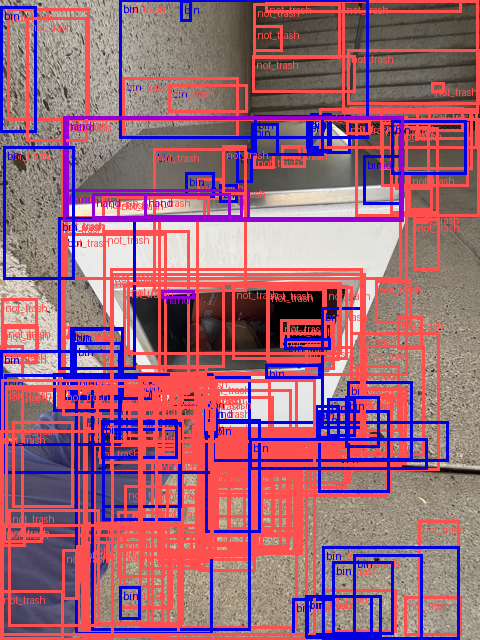

In [110]:
# Get target image and boxes (half them for display purposes in the notebook)
image_to_plot = half_image(random_sample["image"])
boxes_to_plot = half_boxes(random_sample_outputs_post_processed[0]["boxes"])

# Collect the boxes, scores and labels
random_sample_label_names = []
for result in random_sample_outputs_post_processed:
     for score, label_id, box in zip(result["scores"], 
                                     result["labels"], 
                                     result["boxes"]):
         score, label = score.item(), label_id.item()
         box = [round(i, 2) for i in box.tolist()]
         # Optionally print out each prediction 
         # print(f"[INFO] {model.config.id2label[label]}: {score:.2f} {box}")

         random_sample_label_names.append(model.config.id2label[label])

# Get the list of colours to plot
random_sample_colours = [colour_palette[label_name] for label_name in random_sample_label_names]
# print(f"Label names: {random_sample_label_names}")
# print(f"Colour codes: {random_sample_colours}")

# Create the output image with plotted boxes
output_image_with_boxes = to_pil_image(
    pic=draw_bounding_boxes(
        image=pil_to_tensor(pic=image_to_plot),
        boxes=boxes_to_plot,
        labels=random_sample_label_names,
        colors=random_sample_colours,
        width=3,
        # label_colors=random_sample_colours
    )
)
output_image_with_boxes

Reproducing the postprocessed box scores by hand

In [111]:
random_sample_outputs_post_processed[0].keys()

random_sample_outputs_post_processed[0]['scores'], random_sample_outputs_post_processed[0]['scores'].shape

(tensor([0.6277, 0.6252, 0.6201, 0.6192, 0.6083, 0.6050, 0.6042, 0.6037, 0.6035,
         0.6015, 0.5999, 0.5997, 0.5994, 0.5988, 0.5976, 0.5956, 0.5927, 0.5924,
         0.5919, 0.5918, 0.5917, 0.5901, 0.5894, 0.5893, 0.5890, 0.5886, 0.5862,
         0.5854, 0.5850, 0.5849, 0.5848, 0.5847, 0.5841, 0.5814, 0.5810, 0.5808,
         0.5797, 0.5781, 0.5769, 0.5769, 0.5767, 0.5751, 0.5750, 0.5737, 0.5709,
         0.5702, 0.5665, 0.5663, 0.5653, 0.5632, 0.5632, 0.5628, 0.5614, 0.5613,
         0.5610, 0.5606, 0.5603, 0.5598, 0.5596, 0.5591, 0.5585, 0.5579, 0.5578,
         0.5577, 0.5577, 0.5575, 0.5567, 0.5562, 0.5562, 0.5557, 0.5556, 0.5551,
         0.5551, 0.5550, 0.5548, 0.5535, 0.5535, 0.5533, 0.5530, 0.5528, 0.5526,
         0.5519, 0.5505, 0.5502, 0.5498, 0.5496, 0.5493, 0.5493, 0.5484, 0.5476,
         0.5476, 0.5470, 0.5466, 0.5465, 0.5462, 0.5448, 0.5434, 0.5433, 0.5430,
         0.5425, 0.5418, 0.5415, 0.5411, 0.5398, 0.5388, 0.5384, 0.5379, 0.5378,
         0.5373, 0.5365, 0.5

In [112]:
# Get the output scores from our post processed single output
output_scores = random_sample_outputs_post_processed[0]["scores"]
print(len(output_scores), output_scores)

300 tensor([0.6277, 0.6252, 0.6201, 0.6192, 0.6083, 0.6050, 0.6042, 0.6037, 0.6035,
        0.6015, 0.5999, 0.5997, 0.5994, 0.5988, 0.5976, 0.5956, 0.5927, 0.5924,
        0.5919, 0.5918, 0.5917, 0.5901, 0.5894, 0.5893, 0.5890, 0.5886, 0.5862,
        0.5854, 0.5850, 0.5849, 0.5848, 0.5847, 0.5841, 0.5814, 0.5810, 0.5808,
        0.5797, 0.5781, 0.5769, 0.5769, 0.5767, 0.5751, 0.5750, 0.5737, 0.5709,
        0.5702, 0.5665, 0.5663, 0.5653, 0.5632, 0.5632, 0.5628, 0.5614, 0.5613,
        0.5610, 0.5606, 0.5603, 0.5598, 0.5596, 0.5591, 0.5585, 0.5579, 0.5578,
        0.5577, 0.5577, 0.5575, 0.5567, 0.5562, 0.5562, 0.5557, 0.5556, 0.5551,
        0.5551, 0.5550, 0.5548, 0.5535, 0.5535, 0.5533, 0.5530, 0.5528, 0.5526,
        0.5519, 0.5505, 0.5502, 0.5498, 0.5496, 0.5493, 0.5493, 0.5484, 0.5476,
        0.5476, 0.5470, 0.5466, 0.5465, 0.5462, 0.5448, 0.5434, 0.5433, 0.5430,
        0.5425, 0.5418, 0.5415, 0.5411, 0.5398, 0.5388, 0.5384, 0.5379, 0.5378,
        0.5373, 0.5365, 0.5364, 0.53

In [116]:
random_sample_outputs.logits

tensor([[[-0.3871, -0.9509, -0.9556,  ...,  0.3026, -2.2590, -2.9292],
         [-0.4089, -0.9369, -1.1314,  ...,  0.3430, -2.2551, -2.9562],
         [-0.5845, -0.7440, -1.0071,  ...,  0.4044, -2.2340, -2.9747],
         ...,
         [-1.0572, -1.4506, -1.5788,  ..., -0.0262, -2.3242, -3.6714],
         [-0.2051, -0.6684, -1.0932,  ..., -0.0377, -2.1336, -2.8512],
         [-0.6121, -0.6136, -1.0940,  ..., -0.1578, -2.2583, -2.9884]]],
       grad_fn=<SelectBackward0>)

In [118]:
print(f"[INFO] Original input logits shape: {random_sample_outputs.logits.shape}\n") 

# 1. Perform sigmoid on the logits to get prediction probabilities 
output_scores_manual = random_sample_outputs.logits.sigmoid().flatten(start_dim=1)
print(f"[INFO] Manual output scores shape: {output_scores_manual.shape}")
print(f"[INFO] First 10 scores (these will be in random order):\n{output_scores_manual[0][:10].detach().cpu()}\n")

# 2. Get the top 100 scores (we can get any top amount but 100 will do for now) 
output_scores_manual_top_100, output_scores_manual_top_100_indices = torch.topk(input=output_scores_manual,
                                                                                k=100,
                                                                                dim=-1)
print(f"[INFO] Top 100 scores shape: {output_scores_manual_top_100.shape}")
print(f"[INFO] First top 100 score:\n{output_scores_manual_top_100[0][0].item():.4f}\n")

# 3. Find the values above the threshold and create a mask
output_scores_manual_mask = output_scores_manual_top_100 > THRESHOLD

# 4. Sort the top 100 scores which are above the threshold and sort them in descending order and get the indices
output_scores_manual_filtered, output_scores_manual_filtered_indices = torch.sort(input=output_scores_manual_top_100[output_scores_manual_mask], 
                                                                                  descending=True)

print(f"[INFO] Filtered scores shape: {output_scores_manual_filtered.shape}")
print(f"[INFO] First filtered scores:\n{output_scores_manual_filtered[0].detach().cpu():.4f}")

[INFO] Original input logits shape: torch.Size([1, 300, 7])

[INFO] Manual output scores shape: torch.Size([1, 2100])
[INFO] First 10 scores (these will be in random order):
tensor([0.4044, 0.2787, 0.2778, 0.0083, 0.5751, 0.0946, 0.0507, 0.3992, 0.2815,
        0.2439])

[INFO] Top 100 scores shape: torch.Size([1, 100])
[INFO] First top 100 score:
0.6277

[INFO] Filtered scores shape: torch.Size([100])
[INFO] First filtered scores:
0.6277


In [121]:
# Compare the original output scores to our own manual version
torch.isclose(input=output_scores[:len(output_scores_manual_filtered)], 
              other=output_scores_manual_filtered, 
              atol=1e-2)

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])

Reproducing the postprocessed box labels by hand